In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np

In [7]:
base = Path("data")

# Ricarico i file necessari
municipalities = pd.read_csv(base / "municipalities_trentino.csv")
population = pd.read_csv(base / "trentino_population_2021.csv")
incoming = pd.read_csv(base / "incoming_movements_2021.csv")
outcoming = pd.read_csv(base / "outcoming_movements_2021.csv")

# --- 1. Verifica e pulizia dei dati ---

report = {}

# Unicità e presenza id_comune
for name, df in {
    "municipalities": municipalities,
    "population": population,
    "incoming": incoming,
    "outcoming": outcoming,
}.items():
    duplicates = df["id_comune"].duplicated().sum()
    missing = df["id_comune"].isna().sum()
    report[name] = {
        "righe": len(df),
        "duplicati_id": int(duplicates),
        "id_mancanti": int(missing),
        "colonne": list(df.columns),
    }

# Controllo coerenza: lordo = stesso + altro + totale
for name, df in [("incoming", incoming), ("outcoming", outcoming)]:
    df["lordo_ricalc"] = df["stesso"] + df["altro"] + df["totale"]
    df["diff"] = df["lordo"] - df["lordo_ricalc"]
    incoerenti = (df["diff"].abs() > 0).sum()
    report[name]["incoerenze_lordo"] = int(incoerenti)

# Riepilogo
report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "dataset"})
report_df

,dataset,righe,duplicati_id,id_mancanti,colonne,incoerenze_lordo
0,municipalities,166,0,0,"[id_comune, comune, latitude, longitude]",NaN
1,population,166,0,0,"[id_comune, popolazione]",NaN
2,incoming,166,0,0,"[id_comune, comune, stesso, altro, totale, lor...",0
3,outcoming,166,0,0,"[id_comune, comune, stesso, altro, totale, lor...",0


In [9]:
# Punto 2: Controllo coerenza tra i dataset
# - allineamento chiavi (id_comune) tra tutti i file
# - differenze di copertura ID
# - coerenza dei nomi 'comune' rispetto all'anagrafica
# - riepilogo problemi rilevati e record d'esempio



# Normalizza tipi chiave (stringa) per sicurezza
for df in (municipalities, population, incoming, outcoming):
    df["id_comune"] = df["id_comune"].astype(str).str.strip()

# --- 2.1 Copertura e univocità ID ---
coverage = []
for name, df in [("municipalities", municipalities), ("population", population), ("incoming", incoming), ("outcoming", outcoming)]:
    coverage.append({
        "dataset": name,
        "righe": len(df),
        "id_unici": df["id_comune"].nunique(),
        "duplicati_id": int(df["id_comune"].duplicated().sum()),
        "id_null": int(df["id_comune"].isna().sum()),
    })
coverage_df = pd.DataFrame(coverage)
coverage_df


,dataset,righe,id_unici,duplicati_id,id_null
0,municipalities,166,166,0,0
1,population,166,166,0,0
2,incoming,166,166,0,0
3,outcoming,166,166,0,0


In [13]:

# --- 2.2 Differenze di ID tra dataset ---
ids_ref = set(municipalities["id_comune"])
ids_pop = set(population["id_comune"])
ids_inc = set(incoming["id_comune"])
ids_out = set(outcoming["id_comune"])

diff_rows = []
def add_diff_row(label, missing, extra):
    diff_rows.append({
        "confronto_vs_municipalities": label,
        "mancanti_in_altro": len(missing),
        "extra_rispetto_ai_comuni": len(extra),
        "esempi_mancanti": ", ".join(sorted(list(missing))[:5]),
        "esempi_extra": ", ".join(sorted(list(extra))[:5]),
    })

add_diff_row("population", ids_ref - ids_pop, ids_pop - ids_ref)
add_diff_row("incoming", ids_ref - ids_inc, ids_inc - ids_ref)
add_diff_row("outcoming", ids_ref - ids_out, ids_out - ids_ref)

id_diff_df = pd.DataFrame(diff_rows)
print("2.2 Differenze di ID (vs municipalities)") 
id_diff_df


2.2 Differenze di ID (vs municipalities)


,confronto_vs_municipalities,mancanti_in_altro,extra_rispetto_ai_comuni,esempi_mancanti,esempi_extra
0,population,0,0,,
1,incoming,0,0,,
2,outcoming,0,0,,


In [ ]:

# --- 2.3 Coerenza dei nomi 'comune' ---
# Join con anagrafica e confronto dei nomi riportati in incoming/outcoming
inc_names = incoming.merge(municipalities[["id_comune","comune"]].rename(columns={"comune":"comune_anagrafica"}),
                      on="id_comune", how="left")
out_names = outcoming.merge(municipalities[["id_comune","comune"]].rename(columns={"comune":"comune_anagrafica"}),
                      on="id_comune", how="left")

# Normalizzazione dei nomi per confronto robusto (minuscole, strip)
def norm_name(s):
    return s.str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

inc_names["comune_norm"] = norm_name(inc_names["comune"].astype(str))
inc_names["anag_norm"] = norm_name(inc_names["comune_anagrafica"].astype(str))
out_names["comune_norm"] = norm_name(out_names["comune"].astype(str))
out_names["anag_norm"] = norm_name(out_names["comune_anagrafica"].astype(str))

inc_name_issues = inc_names.loc[inc_names["comune_norm"] != inc_names["anag_norm"],
                                ["id_comune","comune","comune_anagrafica"]].copy()
out_name_issues = out_names.loc[out_names["comune_norm"] != out_names["anag_norm"],
                                ["id_comune","comune","comune_anagrafica"]].copy()

# Mostra riepilogo
name_check = pd.DataFrame([
    {"dataset": "incoming", "mismatch_nomi": len(inc_name_issues)},
    {"dataset": "outcoming", "mismatch_nomi": len(out_name_issues)},
])
print("2.3 Riepilogo mismatch di nome (vs anagrafica)") 
name_check


In [15]:
# --- 2.4 Riepilogo id allineati (join qualità) ---
inner_inc = len(pd.merge(municipalities[["id_comune"]], incoming[["id_comune"]], on="id_comune", how="inner"))
inner_out = len(pd.merge(municipalities[["id_comune"]], outcoming[["id_comune"]], on="id_comune", how="inner"))
inner_pop = len(pd.merge(municipalities[["id_comune"]], population[["id_comune"]], on="id_comune", how="inner"))

join_quality = pd.DataFrame([
    {"dataset": "population", "id_in_municipalities": len(ids_ref), "id_in_altro": len(ids_pop), "inner_join_ids": inner_pop},
    {"dataset": "incoming", "id_in_municipalities": len(ids_ref), "id_in_altro": len(ids_inc), "inner_join_ids": inner_inc},
    {"dataset": "outcoming", "id_in_municipalities": len(ids_ref), "id_in_altro": len(ids_out), "inner_join_ids": inner_out},
])
print("2.4 Qualità join (conteggi ID in comune)")
join_quality

2.4 Qualità join (conteggi ID in comune)


,dataset,id_in_municipalities,id_in_altro,inner_join_ids
0,population,166,166,166
1,incoming,166,166,166
2,outcoming,166,166,166


In [16]:
# Conversione tipo per sicurezza
for df in (municipalities, population, incoming, outcoming):
    df["id_comune"] = df["id_comune"].astype(str).str.strip()

# Merge base: popolazione + incoming + outcoming
df = (
    municipalities[["id_comune", "comune"]]
    .merge(population, on="id_comune", how="left")
    .merge(incoming[["id_comune", "lordo", "netto"]].rename(columns={"lordo": "in_lordo", "netto": "in_netto"}), on="id_comune", how="left")
    .merge(outcoming[["id_comune", "stesso", "lordo", "netto"]].rename(columns={"stesso": "out_stesso", "lordo": "out_lordo", "netto": "out_netto"}), on="id_comune", how="left")
)

# Calcolo indicatori
df["lavoratori_in_entrata"] = df["in_lordo"]
df["lavoratori_in_uscita"] = df["out_lordo"]
df["saldo_netto"] = df["in_lordo"] - df["out_lordo"]
df["autocontenimento_pct"] = (df["out_stesso"] / df["out_lordo"]) * 100
df["attrattivita_pct"] = (df["in_netto"] / df["in_lordo"]) * 100
df["intensita_pendolarismo"] = ((df["in_netto"] + df["out_netto"]) / df["popolazione"])
df["indice_bilancio_in_out"] = df["in_lordo"] / df["out_lordo"]

# Gestione divisioni per zero o NaN
df = df.replace([float("inf"), -float("inf")], pd.NA)

# Riorganizzo le colonne per leggibilità
cols = [
    "id_comune", "comune", "popolazione",
    "lavoratori_in_entrata", "lavoratori_in_uscita", "saldo_netto",
    "autocontenimento_pct", "attrattivita_pct", "intensita_pendolarismo", "indice_bilancio_in_out"
]
df_ind = df[cols].copy()

In [17]:

# Mostro anteprima e statistiche descrittive
print("Indicatori base di mobilità") 
df_ind


Indicatori base di mobilità


,id_comune,comune,popolazione,lavoratori_in_entrata,lavoratori_in_uscita,saldo_netto,autocontenimento_pct,attrattivita_pct,intensita_pendolarismo,indice_bilancio_in_out
0,1,Ala,8797,2263,3317,-1054,36.267712,46.840477,0.360805,0.682243
1,2,Albiano,1497,604,548,56,37.591241,65.894040,0.494322,1.102190
2,3,Aldeno,3188,625,1378,-753,21.335269,52.960000,0.443852,0.453556
3,235,Altavalle,1621,260,598,-338,25.919732,40.384615,0.338063,0.434783
4,236,Altopiano della Vigolana,5107,750,2166,-1416,18.651893,46.133333,0.412767,0.346260
...,...,...,...,...,...,...,...,...,...,...
161,222,Villa Lagarina,3853,707,1585,-878,14.511041,67.468175,0.475474,0.446057
162,249,Ville d'Anaunia,4733,1100,1735,-635,32.276657,49.090909,0.362349,0.634006
163,254,Ville di Fiemme,2634,410,1014,-604,23.274162,42.439024,0.361427,0.404339
164,224,Volano,3042,906,1294,-388,20.092736,71.302428,0.552268,0.700155


In [18]:
print("Statistiche descrittive indicatori") 
df_ind.describe(include="all")


Statistiche descrittive indicatori


,id_comune,comune,popolazione,lavoratori_in_entrata,lavoratori_in_uscita,saldo_netto,autocontenimento_pct,attrattivita_pct,intensita_pendolarismo,indice_bilancio_in_out
count,166,166,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
unique,166,166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1,Ala,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,3262.632530,1232.662651,1247.090361,-14.427711,29.548599,52.962745,0.409509,0.688692
std,NaN,NaN,9899.631825,5955.934861,3871.123418,2214.459965,14.708192,15.961294,0.116311,0.376742
min,NaN,NaN,144.000000,13.000000,48.000000,-2050.000000,8.368201,2.222222,0.205664,0.159722
25%,NaN,NaN,714.250000,138.500000,269.500000,-325.500000,19.085704,43.932825,0.344577,0.427672
50%,NaN,NaN,1383.000000,279.500000,523.500000,-133.500000,25.144148,53.042500,0.390925,0.585616
75%,NaN,NaN,2928.500000,749.250000,1105.250000,-37.000000,37.485625,63.231707,0.451676,0.859635


In [19]:
# Punto 4 (aggiornato): Prossimità ai poli principali = TOP 16 comuni per popolazione
# - Forzo i tipi delle chiavi
# - Identifico i 16 più popolosi
# - Calcolo distanza e tempo medi verso questi 16 poli
# - Escludo (dal calcolo della media) l'auto-distanza/auto-tempo se il comune è esso stesso un polo
# - Restituisco un dataframe con risultati e statistiche

dist = pd.read_csv(base / "distance_km_matrix.csv")
time = pd.read_csv(base / "time_hhmm_matrix.csv")

# Normalizzo nomi-comune (utility)
def norm(s: pd.Series) -> pd.Series:
    return s.astype(str).str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

municipalities["comune_norm"] = norm(municipalities["comune"])

# 1) TOP 16 per popolazione (con nomi normalizzati)
top16 = (
    population.merge(municipalities[["id_comune", "comune", "comune_norm"]], on="id_comune", how="left")
       .sort_values("popolazione", ascending=False)
       .head(16)
       .reset_index(drop=True)
)
top16_names_norm = set(top16["comune_norm"].dropna().tolist())

# 2) Preparo le matrici distanza/tempo
dist = dist.rename(columns={dist.columns[0]: "comune"}).copy()
time = time.rename(columns={time.columns[0]: "comune"}).copy()

dist["comune_norm"] = norm(dist["comune"])
time["comune_norm"] = norm(time["comune"])

# Mappa colonne originali -> normalizzate (per selezionare i poli)
dist_cols_norm = {c: norm(pd.Series([c]))[0] for c in dist.columns}
time_cols_norm = {c: norm(pd.Series([c]))[0] for c in time.columns}

# Trova le colonne delle matrici che corrispondono ai top16
dist_polo_cols = [orig for orig, nrm in dist_cols_norm.items() if nrm in top16_names_norm]
time_polo_cols = [orig for orig, nrm in time_cols_norm.items() if nrm in top16_names_norm]

# Rimuovo colonne non numeriche evidenti
dist_polo_cols = [c for c in dist_polo_cols if c != "comune" and c != "comune_norm"]
time_polo_cols = [c for c in time_polo_cols if c != "comune" and c != "comune_norm"]

# Report poli mancanti nelle matrici
present_dist_norm = {dist_cols_norm[c] for c in dist_polo_cols}
present_time_norm = {time_cols_norm[c] for c in time_polo_cols}
missing_in_dist = sorted(list(top16_names_norm - present_dist_norm))
missing_in_time = sorted(list(top16_names_norm - present_time_norm))

poli_report = pd.DataFrame({
    "top10_poli_norm": sorted(list(top16_names_norm)),
    "presente_in_distance": [n not in missing_in_dist for n in sorted(list(top16_names_norm))],
    "presente_in_time": [n not in missing_in_time for n in sorted(list(top16_names_norm))],
})
print("Verifica copertura TOP10 nelle matrici") 
poli_report


Verifica copertura TOP10 nelle matrici


,top10_poli_norm,presente_in_distance,presente_in_time
0,ala,True,True
1,arco,True,True
2,borgo valsugana,True,True
3,cles,True,True
4,lavis,True,True
5,ledro,True,True
6,levico terme,True,True
7,mezzocorona,True,True
8,mezzolombardo,True,True
9,mori,True,True


In [20]:
# 3) Converto i tempi hh:mm in minuti
def hhmm_to_minutes(val):
    if isinstance(val, str) and ":" in val:
        try:
            h, m = val.split(":")
            return int(h) * 60 + int(m)
        except Exception:
            return np.nan
    try:
        # se già numerico (minuti)
        return float(val)
    except Exception:
        return np.nan

time_conv = time.copy()
for c in time_polo_cols:
    time_conv[c] = time_conv[c].apply(hhmm_to_minutes)

# 4) Calcolo media verso i poli (escludendo self se il comune è un polo)
def media_verso_colonne(row, cols, row_name_norm):
    # escludi self se presente nelle colonne
    cols_eff = []
    for c in cols:
        # se la colonna corrisponde al comune della riga, la escludo
        c_norm = time_cols_norm.get(c, dist_cols_norm.get(c))
        if c_norm == row_name_norm:
            continue
        cols_eff.append(c)
    if not cols_eff:
        return np.nan
    vals = row[cols_eff].astype(float)
    vals = vals[vals.notna()]
    return vals.mean() if len(vals) else np.nan

# Applico su distance
dist["dist_media_poli_km"] = dist.apply(
    lambda r: media_verso_colonne(r, dist_polo_cols, r["comune_norm"]),
    axis=1
)

# Applico su time (minuti)
time_conv["tempo_medio_poli_min"] = time_conv.apply(
    lambda r: media_verso_colonne(r, time_polo_cols, r["comune_norm"]),
    axis=1
)

# 5) Merge risultati e aggiungo id_comune dall'anagrafica
prox = dist[["comune", "comune_norm", "dist_media_poli_km"]].merge(
    time_conv[["comune_norm", "tempo_medio_poli_min"]], on="comune_norm", how="left"
).merge(
    municipalities[["id_comune", "comune_norm"]], on="comune_norm", how="left"
)[["id_comune", "comune", "dist_media_poli_km", "tempo_medio_poli_min"]]


In [21]:

# 6) Output
print("Prossimità ai TOP16")
prox


Prossimità ai TOP16


,id_comune,comune,dist_media_poli_km,tempo_medio_poli_min
0,1,Ala,53.233867,45.2000
1,2,Albiano,39.605500,37.5625
2,3,Aldeno,35.456312,33.6250
3,235,Altavalle,43.428562,40.1875
4,236,Altopiano della Vigolana,37.593625,38.9375
...,...,...,...,...
161,222,Villa Lagarina,37.825875,31.5000
162,249,Ville d'Anaunia,52.620750,48.1250
163,254,Ville di Fiemme,68.076750,62.3125
164,224,Volano,37.198313,35.5625


In [22]:
print("Statistiche descrittive prossimità TOP16")
prox[["dist_media_poli_km", "tempo_medio_poli_min"]].describe()

Statistiche descrittive prossimità TOP16


,dist_media_poli_km,tempo_medio_poli_min
count,166.000000,166.000000
mean,57.025571,54.184413
std,16.296642,17.032821
min,34.338133,31.000000
25%,43.773266,40.390625
50%,55.037625,51.593750
75%,66.675172,63.250000
max,111.957125,117.937500


In [27]:
# Tabella finale: indicatori di mobilità + prossimità ai TOP16 più popolosi
# - Ricostruisco gli indicatori del punto 3 (separatamente) per sicurezza
# - Calcolo prossimità ai TOP16 (distanza/tempo medi)
# - Unisco tutto in un unico dataframe e lo salvo come CSV


# --- Normalizzazioni ---
for df in (municipalities, population, incoming, outcoming):
    df["id_comune"] = df["id_comune"].astype(str).str.strip()

def norm(s: pd.Series) -> pd.Series:
    return s.astype(str).str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

municipalities["comune_norm"] = norm(municipalities["comune"])

# --- (A) Indicatori di mobilità (punto 3) ---
mob = (
    municipalities[["id_comune", "comune"]]
    .merge(population, on="id_comune", how="left")
    .merge(incoming[["id_comune", "lordo", "netto"]].rename(columns={"lordo": "in_lordo", "netto": "in_netto"}), on="id_comune", how="left")
    .merge(outcoming[["id_comune", "stesso", "lordo", "netto"]].rename(columns={"stesso": "out_stesso", "lordo": "out_lordo", "netto": "out_netto"}), on="id_comune", how="left")
)

mob["lavoratori_in_entrata"] = mob["in_lordo"]
mob["lavoratori_in_uscita"] = mob["out_lordo"]
mob["saldo_netto"] = mob["in_lordo"] - mob["out_lordo"]
mob["autocontenimento_pct"] = (mob["out_stesso"] / mob["out_lordo"]) * 100
mob["attrattivita_pct"] = (mob["in_netto"] / mob["in_lordo"]) * 100
mob["intensita_pendolarismo"] = ((mob["in_netto"] + mob["out_netto"]) / mob["popolazione"])
mob["indice_bilancio_in_out"] = mob["in_lordo"] / mob["out_lordo"]
mob = mob.replace([float("inf"), -float("inf")], pd.NA)

mob_base_cols = [
    "id_comune", "comune", "popolazione",
    "lavoratori_in_entrata", "lavoratori_in_uscita", "saldo_netto",
    "autocontenimento_pct", "attrattivita_pct", "intensita_pendolarismo", "indice_bilancio_in_out"
]
mob = mob[mob_base_cols].copy()

# --- (B) Prossimità ai TOP16 ---

# 1) Identifica TOP16 più popolosi (con nomi normalizzati)
top16 = (
    population.merge(municipalities[["id_comune", "comune", "comune_norm"]], on="id_comune", how="left")
       .sort_values("popolazione", ascending=False)
       .head(16)
       .reset_index(drop=True)
)
top16_names_norm = set(top16["comune_norm"].dropna().tolist())

# 2) Prepara matrici distanza/tempo con nomi normalizzati
dist = dist.rename(columns={dist.columns[0]: "comune"}).copy()
time = time.rename(columns={time.columns[0]: "comune"}).copy()

dist["comune_norm"] = norm(dist["comune"])
time["comune_norm"] = norm(time["comune"])

# mapping colonne originali -> nomi normalizzati
def columns_norm_map(df):
    return {c: norm(pd.Series([c]))[0] for c in df.columns}

dist_cols_norm = columns_norm_map(dist)
time_cols_norm = columns_norm_map(time)

# colonne che corrispondono ai top16
dist_polo_cols = [orig for orig, nrm in dist_cols_norm.items() if nrm in top16_names_norm and orig not in ("comune", "comune_norm")]
time_polo_cols = [orig for orig, nrm in time_cols_norm.items() if nrm in top16_names_norm and orig not in ("comune", "comune_norm")]

# 3) Converte hh:mm -> minuti
def hhmm_to_minutes(val):
    if isinstance(val, str) and ":" in val:
        try:
            h, m = val.split(":")
            return int(h) * 60 + int(m)
        except Exception:
            return np.nan
    try:
        return float(val)
    except Exception:
        return np.nan

time_conv = time.copy()
for c in time_polo_cols:
    time_conv[c] = time_conv[c].apply(hhmm_to_minutes)

# 4) Funzione media verso poli (esclude self se presente)
def media_verso_colonne(row, cols, row_name_norm):
    cols_eff = []
    for c in cols:
        c_norm = time_cols_norm.get(c, dist_cols_norm.get(c))
        if c_norm == row_name_norm:
            continue
        cols_eff.append(c)
    if not cols_eff:
        return np.nan
    vals = row[cols_eff].astype(float)
    vals = vals[vals.notna()]
    return vals.mean() if len(vals) else np.nan

# 5) Calcola prossimità
dist["dist_media_poli_km_16"] = dist.apply(
    lambda r: media_verso_colonne(r, dist_polo_cols, r["comune_norm"]),
    axis=1
)

time_conv["tempo_medio_poli_min_16"] = time_conv.apply(
    lambda r: media_verso_colonne(r, time_polo_cols, r["comune_norm"]),
    axis=1
)

prox16 = dist[["comune_norm", "dist_media_poli_km_16"]].merge(
    time_conv[["comune_norm", "tempo_medio_poli_min_16"]], on="comune_norm", how="left"
).merge(
    municipalities[["id_comune", "comune", "comune_norm"]], on="comune_norm", how="left"
)[["id_comune", "comune", "dist_media_poli_km_16", "tempo_medio_poli_min_16"]]

# --- (C) Merge finale ---
final = mob.merge(prox16, on=["id_comune", "comune"], how="left")

# Ordine colonne
final = final[[
    "id_comune", "comune", "popolazione",
    "lavoratori_in_entrata", "lavoratori_in_uscita", "saldo_netto",
    "autocontenimento_pct", "attrattivita_pct", "intensita_pendolarismo", "indice_bilancio_in_out",
    "dist_media_poli_km_16", "tempo_medio_poli_min_16"
]]

# Mostra e salva
print("Tabella finale indicatori (mobilità + prossimità TOP16)")
final.head(15)


Tabella finale indicatori (mobilità + prossimità TOP16)


,id_comune,comune,popolazione,lavoratori_in_entrata,lavoratori_in_uscita,saldo_netto,autocontenimento_pct,attrattivita_pct,intensita_pendolarismo,indice_bilancio_in_out,dist_media_poli_km_16,tempo_medio_poli_min_16
0,1,Ala,8797,2263,3317,-1054,36.267712,46.840477,0.360805,0.682243,53.233867,45.2000
1,2,Albiano,1497,604,548,56,37.591241,65.894040,0.494322,1.102190,39.605500,37.5625
2,3,Aldeno,3188,625,1378,-753,21.335269,52.960000,0.443852,0.453556,35.456312,33.6250
3,235,Altavalle,1621,260,598,-338,25.919732,40.384615,0.338063,0.434783,43.428562,40.1875
4,236,Altopiano della Vigolana,5107,750,2166,-1416,18.651893,46.133333,0.412767,0.346260,37.593625,38.9375
5,237,Amblar-Don,547,126,203,-77,32.512315,47.619048,0.360146,0.620690,61.704813,57.7500
6,5,Andalo,1207,650,380,270,71.315789,58.307692,0.404308,1.710526,49.312687,43.8750
7,6,Arco,17745,8344,6866,1478,58.258083,52.061361,0.406312,1.215264,47.144867,44.2000
8,7,Avio,4090,1336,1560,-224,42.371795,50.523952,0.384841,0.856410,56.230625,43.8125
9,9,Baselga di Pinè,5086,1037,1976,-939,30.617409,41.658631,0.354503,0.524798,42.426063,40.3125


In [28]:

out_path = base / "indicatori_mobilita_prossimita_top16.csv"
final.to_csv(out_path, index=False)

print(f"Salvato CSV: {out_path}")


Salvato CSV: data/indicatori_mobilita_prossimita_top16.csv



- Analizzare correlazioni fra indicatori di mobilità e prossimità.
- Evidenziare tendenze generali (es. comuni lontani più autosufficienti?).
- Preparare i dati per cluster o visualizzazioni successive.

*indicatori*
|Mobilità|Accessibilità|
|--------|-------------|
|Autocontenimento (%)|Distanza media dai TOP16 (km)|
|Attrattività (%)|Distanza media dai TOP16 (km)|
|Intensità pendolarismo|Tempo medio dai TOP16 (min)|
|Indice bilancio in/out|Distanza + tempo medi|

- Calcolo matrice di correlazione (Pearson) fra tutti gli indicatori.
- Evidenziare i coefficienti più forti (positivi e negativi).
- Identificare comuni estremi/outlier:
- alta attrattività ma molto distanti;
- alto autocontenimento e grande distanza.
- Grafici di correlazione scatter + linee di tendenza.

In [29]:
# Punto 5: Analisi integrata mobilità ↔ accessibilità
# - Calcolo matrice di correlazione (Pearson)
# - Identificazione relazioni più forti
# - Estrazione outlier comuni estremi (autocontenimento vs distanza, attrattività vs distanza)



final_path = base / "indicatori_mobilita_prossimita_top16.csv"

# Caricamento tabella finale
df = pd.read_csv(final_path)

# Seleziono solo colonne numeriche per la correlazione
numeric_cols = [
    "popolazione",
    "lavoratori_in_entrata", "lavoratori_in_uscita", "saldo_netto",
    "autocontenimento_pct", "attrattivita_pct", "intensita_pendolarismo",
    "indice_bilancio_in_out",
    "dist_media_poli_km_16", "tempo_medio_poli_min_16"
]

corr = df[numeric_cols].corr(method="pearson").round(3)

# Ordina per forza assoluta di correlazione rispetto ai due indicatori di prossimità
corr_focus = corr[["dist_media_poli_km_16", "tempo_medio_poli_min_16"]].copy()
corr_focus["media_assoluta"] = corr_focus.abs().mean(axis=1)
corr_focus = corr_focus.sort_values("media_assoluta", ascending=False)

# Individua outlier interessanti
q_low = df["dist_media_poli_km_16"].quantile(0.25)
q_high = df["dist_media_poli_km_16"].quantile(0.75)
auto_high = df["autocontenimento_pct"].quantile(0.75)
attr_high = df["attrattivita_pct"].quantile(0.75)

# Comuni lontani ma autosufficienti
auto_outliers = df[(df["dist_media_poli_km_16"] > q_high) & (df["autocontenimento_pct"] > auto_high)]
# Comuni lontani ma molto attrattivi
attr_outliers = df[(df["dist_media_poli_km_16"] > q_high) & (df["attrattivita_pct"] > attr_high)]

# Mostra risultati
print("5.1 Matrice di correlazione (Pearson)") 
corr

5.1 Matrice di correlazione (Pearson)


,popolazione,lavoratori_in_entrata,lavoratori_in_uscita,saldo_netto,autocontenimento_pct,attrattivita_pct,intensita_pendolarismo,indice_bilancio_in_out,dist_media_poli_km_16,tempo_medio_poli_min_16
popolazione,1.000,0.988,1.000,0.910,0.399,-0.033,-0.026,0.266,-0.185,-0.190
lavoratori_in_entrata,0.988,1.000,0.988,0.963,0.386,-0.007,-0.000,0.286,-0.146,-0.150
lavoratori_in_uscita,1.000,0.988,1.000,0.909,0.385,-0.028,-0.017,0.258,-0.195,-0.200
saldo_netto,0.910,0.963,0.909,1.000,0.366,0.030,0.030,0.318,-0.051,-0.053
autocontenimento_pct,0.399,0.386,0.385,0.366,1.000,-0.208,-0.297,0.658,0.304,0.266
attrattivita_pct,-0.033,-0.007,-0.028,0.030,-0.208,1.000,0.827,0.476,-0.038,-0.027
intensita_pendolarismo,-0.026,-0.000,-0.017,0.030,-0.297,0.827,1.000,0.489,-0.241,-0.227
indice_bilancio_in_out,0.266,0.286,0.258,0.318,0.658,0.476,0.489,1.000,0.206,0.186
dist_media_poli_km_16,-0.185,-0.146,-0.195,-0.051,0.304,-0.038,-0.241,0.206,1.000,0.986
tempo_medio_poli_min_16,-0.190,-0.150,-0.200,-0.053,0.266,-0.027,-0.227,0.186,0.986,1.000


In [30]:
print("5.2 Indicatori più correlati con la distanza/tempo")
corr_focus


5.2 Indicatori più correlati con la distanza/tempo


,dist_media_poli_km_16,tempo_medio_poli_min_16,media_assoluta
dist_media_poli_km_16,1.000,0.986,0.9930
tempo_medio_poli_min_16,0.986,1.000,0.9930
autocontenimento_pct,0.304,0.266,0.2850
intensita_pendolarismo,-0.241,-0.227,0.2340
lavoratori_in_uscita,-0.195,-0.200,0.1975
indice_bilancio_in_out,0.206,0.186,0.1960
popolazione,-0.185,-0.190,0.1875
lavoratori_in_entrata,-0.146,-0.150,0.1480
saldo_netto,-0.051,-0.053,0.0520
attrattivita_pct,-0.038,-0.027,0.0325


In [31]:
print("5.3 Comuni lontani ma autosufficienti") 
auto_outliers[["comune", "autocontenimento_pct", "dist_media_poli_km_16"]]

5.3 Comuni lontani ma autosufficienti


,comune,autocontenimento_pct,dist_media_poli_km_16
16,Borgo Chiese,43.239227,72.021187
27,Campitello di Fassa / Ciampedel,41.666667,98.056313
29,Canal San Bovo,47.173913,92.023813
30,Canazei / Cianacei,76.607143,100.497313
56,Dimaro Folgarida,42.503439,70.256125
79,Malé,42.053446,67.987437
82,Mezzana,39.735099,76.044438
86,Moena / Moena,57.901554,83.648500
98,Peio,45.794393,92.648813
99,Pellizzano,38.075314,79.551063


In [32]:
print("5.4 Comuni lontani ma attrattivi") 
attr_outliers[["comune", "attrattivita_pct", "dist_media_poli_km_16"]]

5.4 Comuni lontani ma attrattivi


,comune,attrattivita_pct,dist_media_poli_km_16
16,Borgo Chiese,71.829622,72.021187
34,Castel Condino,81.818182,74.433563
46,Cinte Tesino,75.824176,67.081875
67,Giustino,67.682927,68.939937
79,Malé,69.175258,67.987437
80,Massimeno,78.125000,69.995000
97,Panchià,66.666667,70.223938
102,Pieve di Bono-Prezzo,65.745856,70.660000
104,Pinzolo,64.143921,70.177750
140,Strembo,72.435897,66.680312


In [33]:
# Punto 6: Sintesi per storytelling
# - Ricostruisce gli indicatori (mobilità + prossimità TOP16) in modo autonomo
# - Calcola medie provinciali e classi sopra/sotto media
# - Aggiunge delta e z-score per ciascun indicatore
# - Esporta un CSV "indicatori_sintesi.csv" pronto per visualizzazioni/report


# -----------------------------
# Utility
# -----------------------------
def norm(s: pd.Series) -> pd.Series:
    return s.astype(str).str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

def hhmm_to_minutes(val):
    if isinstance(val, str) and ":" in val:
        try:
            h, m = val.split(":")
            return int(h) * 60 + int(m)
        except Exception:
            return np.nan
    try:
        return float(val)
    except Exception:
        return np.nan

def columns_norm_map(df):
    return {c: norm(pd.Series([c]))[0] for c in df.columns}

def media_verso_colonne(row, cols, row_name_norm, col_norm_map):
    # esclude self (se la colonna corrisponde al comune della riga)
    cols_eff = []
    for c in cols:
        c_norm = col_norm_map.get(c)
        if c_norm == row_name_norm:
            continue
        cols_eff.append(c)
    if not cols_eff:
        return np.nan
    vals = row[cols_eff].astype(float)
    vals = vals[vals.notna()]
    return vals.mean() if len(vals) else np.nan



# -----------------------------
# (A) Indicatori di mobilità (punto 3)
# -----------------------------
mob = (
    municipalities[["id_comune", "comune"]]
    .merge(population, on="id_comune", how="left")
    .merge(incoming[["id_comune", "lordo", "netto"]].rename(columns={"lordo": "in_lordo", "netto": "in_netto"}), on="id_comune", how="left")
    .merge(outcoming[["id_comune", "stesso", "lordo", "netto"]].rename(columns={"stesso": "out_stesso", "lordo": "out_lordo", "netto": "out_netto"}), on="id_comune", how="left")
)

mob["lavoratori_in_entrata"] = mob["in_lordo"]
mob["lavoratori_in_uscita"] = mob["out_lordo"]
mob["saldo_netto"] = mob["in_lordo"] - mob["out_lordo"]
mob["autocontenimento_pct"] = (mob["out_stesso"] / mob["out_lordo"]) * 100
mob["attrattivita_pct"] = (mob["in_netto"] / mob["in_lordo"]) * 100
mob["intensita_pendolarismo"] = ((mob["in_netto"] + mob["out_netto"]) / mob["popolazione"])
mob["indice_bilancio_in_out"] = mob["in_lordo"] / mob["out_lordo"]
mob = mob.replace([float("inf"), -float("inf")], pd.NA)

mob = mob[[
    "id_comune", "comune", "popolazione",
    "lavoratori_in_entrata", "lavoratori_in_uscita", "saldo_netto",
    "autocontenimento_pct", "attrattivita_pct", "intensita_pendolarismo", "indice_bilancio_in_out"
]].copy()

# -----------------------------
# (B) Prossimità ai TOP16 più popolosi
# -----------------------------
top16 = (
    population.merge(municipalities[["id_comune", "comune", "comune_norm"]], on="id_comune", how="left")
       .sort_values("popolazione", ascending=False)
       .head(16)
       .reset_index(drop=True)
)
top16_names_norm = set(top16["comune_norm"].dropna().tolist())

# Preparo le matrici e normalizzo
dist = dist.rename(columns={dist.columns[0]: "comune"}).copy()
time = time.rename(columns={time.columns[0]: "comune"}).copy()

dist["comune_norm"] = norm(dist["comune"])
time["comune_norm"] = norm(time["comune"])

dist_cols_norm = columns_norm_map(dist)
time_cols_norm = columns_norm_map(time)

# Individuo le colonne che corrispondono ai TOP16
dist_polo_cols = [orig for orig, nrm in dist_cols_norm.items() if nrm in top16_names_norm and orig not in ("comune", "comune_norm")]
time_polo_cols = [orig for orig, nrm in time_cols_norm.items() if nrm in top16_names_norm and orig not in ("comune", "comune_norm")]

# Converto tempi h:mm in minuti
time_conv = time.copy()
for c in time_polo_cols:
    time_conv[c] = time_conv[c].apply(hhmm_to_minutes)

# Calcolo distanze/tempi medi verso TOP16
dist["dist_media_poli_km_16"] = dist.apply(
    lambda r: media_verso_colonne(r, dist_polo_cols, norm(pd.Series([r["comune"]]))[0], dist_cols_norm),
    axis=1
)
time_conv["tempo_medio_poli_min_16"] = time_conv.apply(
    lambda r: media_verso_colonne(r, time_polo_cols, norm(pd.Series([r["comune"]]))[0], time_cols_norm),
    axis=1
)

prox16 = dist[["comune_norm", "dist_media_poli_km_16"]].merge(
    time_conv[["comune_norm", "tempo_medio_poli_min_16"]], on="comune_norm", how="left"
).merge(
    municipalities[["id_comune", "comune", "comune_norm"]], on="comune_norm", how="left"
)[["id_comune", "comune", "dist_media_poli_km_16", "tempo_medio_poli_min_16"]]

# -----------------------------
# (C) Merge finale + sintesi
# -----------------------------
final = mob.merge(prox16, on=["id_comune", "comune"], how="left")

# Elenco indicatori da sintetizzare
indicators = [
    "autocontenimento_pct",
    "attrattivita_pct",
    "intensita_pendolarismo",
    "indice_bilancio_in_out",
    "dist_media_poli_km_16",
    "tempo_medio_poli_min_16"
]

# Calcolo media provinciale, delta, z-score, e classe sopra/sotto media
sintesi_cols = {}
for col in indicators:
    media = final[col].mean(skipna=True)
    std = final[col].std(skipna=True)
    final[f"{col}_media_prov"] = media
    final[f"{col}_delta"] = final[col] - media
    final[f"{col}_zscore"] = (final[col] - media) / std if std and not np.isnan(std) and std != 0 else np.nan
    # Classe sopra/sotto media (per distanza/tempo "sopra media" = più lontano/lento)
    final[f"{col}_class"] = np.where(final[col] >= media, "sopra_media", "sotto_media")

# Ordino colonne per leggibilità
ordered = [
    "id_comune", "comune", "popolazione",
    "lavoratori_in_entrata", "lavoratori_in_uscita", "saldo_netto",
    "autocontenimento_pct", "autocontenimento_pct_media_prov", "autocontenimento_pct_delta", "autocontenimento_pct_zscore", "autocontenimento_pct_class",
    "attrattivita_pct", "attrattivita_pct_media_prov", "attrattivita_pct_delta", "attrattivita_pct_zscore", "attrattivita_pct_class",
    "intensita_pendolarismo", "intensita_pendolarismo_media_prov", "intensita_pendolarismo_delta", "intensita_pendolarismo_zscore", "intensita_pendolarismo_class",
    "indice_bilancio_in_out", "indice_bilancio_in_out_media_prov", "indice_bilancio_in_out_delta", "indice_bilancio_in_out_zscore", "indice_bilancio_in_out_class",
    "dist_media_poli_km_16", "dist_media_poli_km_16_media_prov", "dist_media_poli_km_16_delta", "dist_media_poli_km_16_zscore", "dist_media_poli_km_16_class",
    "tempo_medio_poli_min_16", "tempo_medio_poli_min_16_media_prov", "tempo_medio_poli_min_16_delta", "tempo_medio_poli_min_16_zscore", "tempo_medio_poli_min_16_class",
]

final_sintesi = final[ordered].copy()

print("Punto 6 — Indicatori con media, delta, z-score e classi")
final_sintesi


Punto 6 — Indicatori con media, delta, z-score e classi


,id_comune,comune,popolazione,lavoratori_in_entrata,lavoratori_in_uscita,saldo_netto,autocontenimento_pct,autocontenimento_pct_media_prov,autocontenimento_pct_delta,autocontenimento_pct_zscore,...,dist_media_poli_km_16,dist_media_poli_km_16_media_prov,dist_media_poli_km_16_delta,dist_media_poli_km_16_zscore,dist_media_poli_km_16_class,tempo_medio_poli_min_16,tempo_medio_poli_min_16_media_prov,tempo_medio_poli_min_16_delta,tempo_medio_poli_min_16_zscore,tempo_medio_poli_min_16_class
0,1,Ala,8797,2263,3317,-1054,36.267712,29.548599,6.719112,0.456828,...,53.233867,57.025571,-3.791705,-0.232668,sotto_media,45.2000,54.184413,-8.984413,-0.527476,sotto_media
1,2,Albiano,1497,604,548,56,37.591241,29.548599,8.042641,0.546814,...,39.605500,57.025571,-17.420071,-1.068936,sotto_media,37.5625,54.184413,-16.621913,-0.975875,sotto_media
2,3,Aldeno,3188,625,1378,-753,21.335269,29.548599,-8.213331,-0.558419,...,35.456312,57.025571,-21.569259,-1.323540,sotto_media,33.6250,54.184413,-20.559413,-1.207047,sotto_media
3,235,Altavalle,1621,260,598,-338,25.919732,29.548599,-3.628867,-0.246724,...,43.428562,57.025571,-13.597009,-0.834344,sotto_media,40.1875,54.184413,-13.996913,-0.821761,sotto_media
4,236,Altopiano della Vigolana,5107,750,2166,-1416,18.651893,29.548599,-10.896707,-0.740860,...,37.593625,57.025571,-19.431946,-1.192390,sotto_media,38.9375,54.184413,-15.246913,-0.895149,sotto_media
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,222,Villa Lagarina,3853,707,1585,-878,14.511041,29.548599,-15.037558,-1.022393,...,37.825875,57.025571,-19.199696,-1.178138,sotto_media,31.5000,54.184413,-22.684413,-1.331806,sotto_media
162,249,Ville d'Anaunia,4733,1100,1735,-635,32.276657,29.548599,2.728058,0.185479,...,52.620750,57.025571,-4.404821,-0.270290,sotto_media,48.1250,54.184413,-6.059413,-0.355749,sotto_media
163,254,Ville di Fiemme,2634,410,1014,-604,23.274162,29.548599,-6.274438,-0.426595,...,68.076750,57.025571,11.051179,0.678126,sopra_media,62.3125,54.184413,8.128087,0.477201,sopra_media
164,224,Volano,3042,906,1294,-388,20.092736,29.548599,-9.455864,-0.642898,...,37.198313,57.025571,-19.827259,-1.216647,sotto_media,35.5625,54.184413,-18.621913,-1.093296,sotto_media


In [37]:


# Riepilogo medie provinciali (una sola riga)
medie = {col: final[col].mean(skipna=True) for col in indicators}
medie_df = pd.DataFrame([medie])

print("Medie provinciali per indicatori chiave")
medie_df



Medie provinciali per indicatori chiave


,autocontenimento_pct,attrattivita_pct,intensita_pendolarismo,indice_bilancio_in_out,dist_media_poli_km_16,tempo_medio_poli_min_16
0,29.548599,52.962745,0.409509,0.688692,57.025571,54.184413


In [36]:

# Salva CSV
out_path = base / "indicatori_sintesi.csv"
final_sintesi.to_csv(out_path, index=False)

print(f"Creato file di sintesi: {out_path}")

Creato file di sintesi: data/indicatori_sintesi.csv


In [38]:
# Punto 6B: Tabella confronto vs media + grafici base
# - Crea tabella semplificata per schede comunali (frecce ↑ / ↓)
# - Genera 3 grafici base per storytelling



df = pd.read_csv(base / "indicatori_sintesi.csv")

# -----------------------------
# (A) Tabella “Confronto vs media provinciale”
# -----------------------------

def arrow_class(val):
    if isinstance(val, str):
        return "▲" if val == "sopra_media" else "▼"
    return ""

cols_compare = [
    "autocontenimento_pct_class",
    "attrattivita_pct_class",
    "intensita_pendolarismo_class",
    "indice_bilancio_in_out_class",
    "dist_media_poli_km_16_class",
    "tempo_medio_poli_min_16_class"
]

rename_cols = {
    "autocontenimento_pct_class": "Autocontenimento",
    "attrattivita_pct_class": "Attrattività",
    "intensita_pendolarismo_class": "Intensità Pendolarismo",
    "indice_bilancio_in_out_class": "Bilancio In/Out",
    "dist_media_poli_km_16_class": "Distanza Media Poli",
    "tempo_medio_poli_min_16_class": "Tempo Medio Poli"
}

tabella_confronto = df[["comune"] + cols_compare].copy()
for c in cols_compare:
    tabella_confronto[c] = tabella_confronto[c].apply(arrow_class)
tabella_confronto = tabella_confronto.rename(columns=rename_cols)

print("Tabella confronto vs media provinciale (frecce)")
tabella_confronto


Tabella confronto vs media provinciale (frecce)


,comune,Autocontenimento,Attrattività,Intensità Pendolarismo,Bilancio In/Out,Distanza Media Poli,Tempo Medio Poli
0,Ala,▲,▼,▼,▼,▼,▼
1,Albiano,▲,▲,▲,▲,▼,▼
2,Aldeno,▼,▼,▲,▼,▼,▼
3,Altavalle,▼,▼,▼,▼,▼,▼
4,Altopiano della Vigolana,▼,▼,▲,▼,▼,▼
...,...,...,...,...,...,...,...
161,Villa Lagarina,▼,▲,▲,▼,▼,▼
162,Ville d'Anaunia,▲,▼,▼,▼,▼,▼
163,Ville di Fiemme,▼,▼,▼,▼,▲,▲
164,Volano,▼,▲,▲,▲,▼,▼


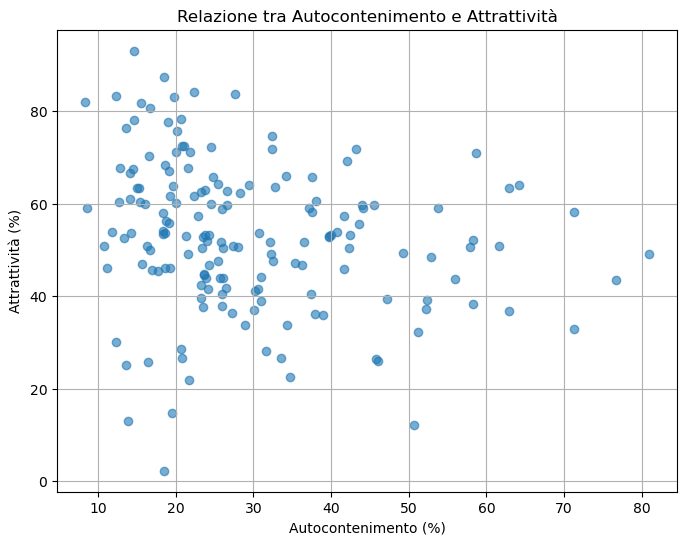

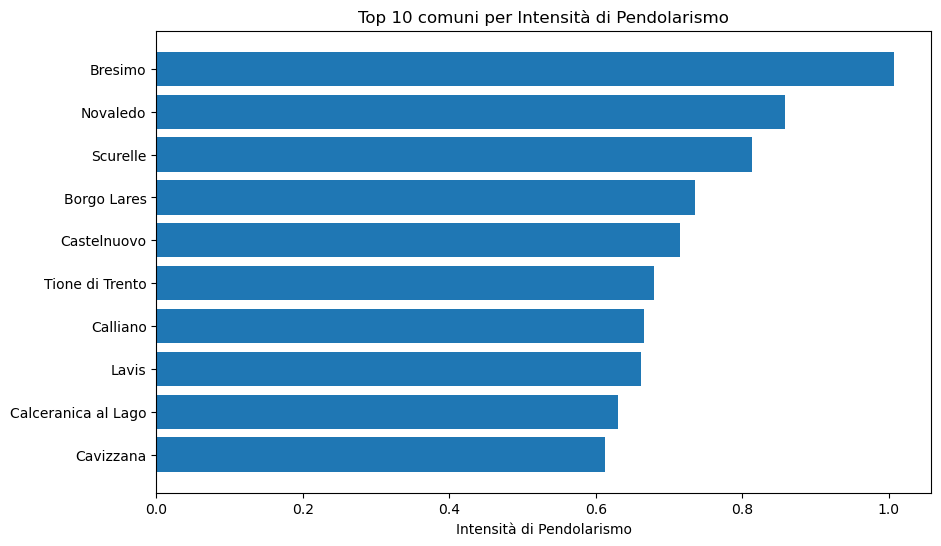

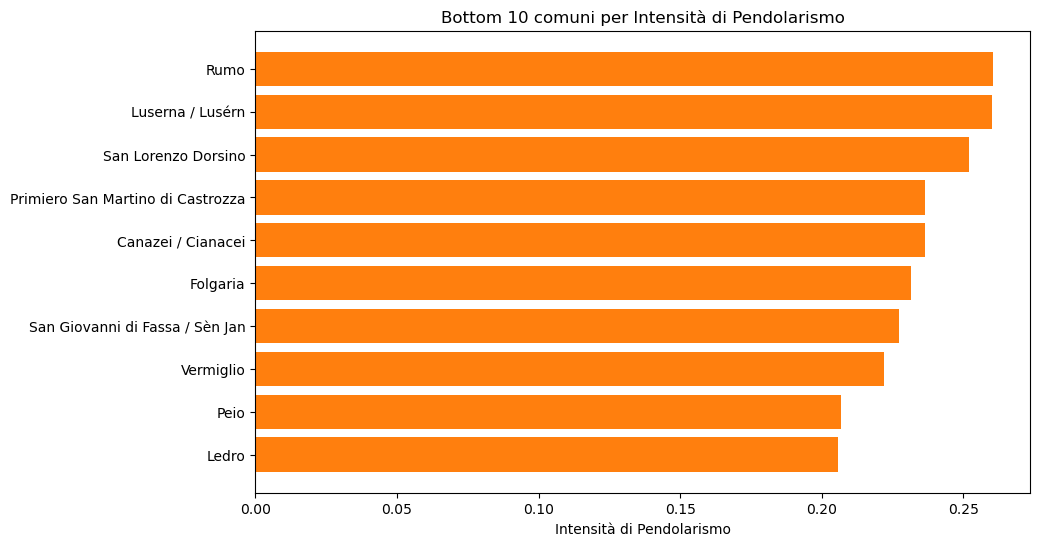

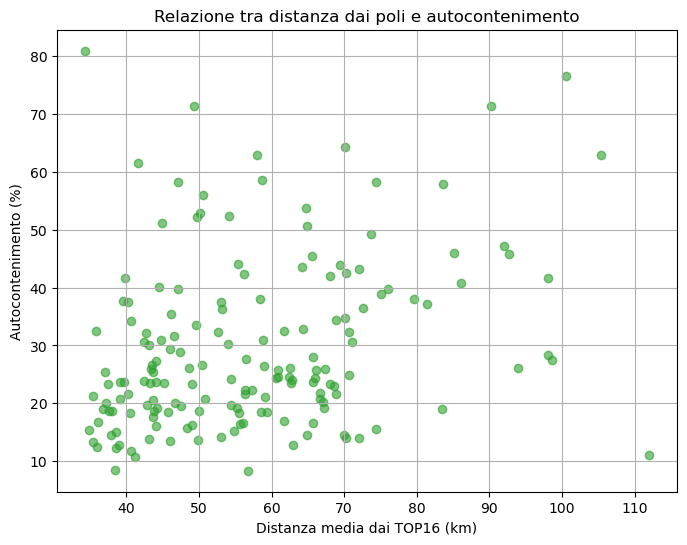

Punto 6B completato: tabella confronto e grafici base generati.


In [39]:
import matplotlib.pyplot as plt
# -----------------------------
# (B) Grafici base
# -----------------------------

# Scatter 1: Autocontenimento vs Attrattività
plt.figure(figsize=(8,6))
plt.scatter(df["autocontenimento_pct"], df["attrattivita_pct"], alpha=0.6)
plt.xlabel("Autocontenimento (%)")
plt.ylabel("Attrattività (%)")
plt.title("Relazione tra Autocontenimento e Attrattività")
plt.grid(True)
plt.show()

# Bar chart: Top10 e Bottom10 per Intensità pendolarismo
df_sorted = df.sort_values("intensita_pendolarismo", ascending=False)
top10 = df_sorted.head(10)
bottom10 = df_sorted.tail(10)

plt.figure(figsize=(10,6))
plt.barh(top10["comune"], top10["intensita_pendolarismo"], color="tab:blue")
plt.title("Top 10 comuni per Intensità di Pendolarismo")
plt.xlabel("Intensità di Pendolarismo")
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(10,6))
plt.barh(bottom10["comune"], bottom10["intensita_pendolarismo"], color="tab:orange")
plt.title("Bottom 10 comuni per Intensità di Pendolarismo")
plt.xlabel("Intensità di Pendolarismo")
plt.gca().invert_yaxis()
plt.show()

# Scatter 2: Distanza media vs Autocontenimento
plt.figure(figsize=(8,6))
plt.scatter(df["dist_media_poli_km_16"], df["autocontenimento_pct"], alpha=0.6, color="tab:green")
plt.xlabel("Distanza media dai TOP16 (km)")
plt.ylabel("Autocontenimento (%)")
plt.title("Relazione tra distanza dai poli e autocontenimento")
plt.grid(True)
plt.show()

print("Punto 6B completato: tabella confronto e grafici base generati.")


In [40]:
# Punto 7: Clustering dei comuni per profili di mobilità e accessibilità
# - Usa i principali indicatori standardizzati
# - Applica K-means con 4 cluster
# - Riassume le caratteristiche medie di ogni cluster
# - Aggiunge etichetta interpretativa


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv(base / "indicatori_sintesi.csv")

# -----------------------------
# (A) Scelta variabili per clustering
# -----------------------------
cols_cluster = [
    "autocontenimento_pct",
    "attrattivita_pct",
    "intensita_pendolarismo",
    "indice_bilancio_in_out",
    "dist_media_poli_km_16",
    "tempo_medio_poli_min_16"
]

X = df[cols_cluster].copy()
X = X.fillna(X.mean())  # sostituisce eventuali NaN con la media

# Standardizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# (B) K-means clustering
# -----------------------------
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# -----------------------------
# (C) Profilo medio per cluster
# -----------------------------
cluster_profile = df.groupby("cluster")[cols_cluster].mean().round(2)
cluster_profile["n_comuni"] = df["cluster"].value_counts().sort_index()

# -----------------------------
# (D) Etichettatura interpretativa (approssimata)
# -----------------------------
def label_cluster(row):
    if row["attrattivita_pct"] > row["autocontenimento_pct"] and row["intensita_pendolarismo"] > 0.2:
        return "Polo attrattivo"
    elif row["autocontenimento_pct"] > 70 and row["dist_media_poli_km_16"] > row["dist_media_poli_km_16"].mean():
        return "Comune autosufficiente e distante"
    elif row["intensita_pendolarismo"] < 0.1 and row["attrattivita_pct"] < 20:
        return "Comune stabile a bassa mobilità"
    else:
        return "Comune misto / cintura"

cluster_profile["profilo_descrittivo"] = cluster_profile.apply(label_cluster, axis=1)


In [42]:

print("7.1 Profilo medio per cluster") 
cluster_profile


7.1 Profilo medio per cluster


,autocontenimento_pct,attrattivita_pct,intensita_pendolarismo,indice_bilancio_in_out,dist_media_poli_km_16,tempo_medio_poli_min_16,n_comuni,profilo_descrittivo
cluster,,,,,,,,
0,19.25,64.20,0.46,0.57,51.31,48.78,57,Polo attrattivo
1,42.32,47.28,0.32,0.81,86.69,84.95,23,Polo attrattivo
2,44.06,67.54,0.56,1.40,55.79,52.19,23,Polo attrattivo
3,28.91,39.55,0.34,0.50,51.82,48.58,63,Polo attrattivo


In [43]:
print("7.2 Assegnazione cluster per comuni") 
df[["comune", "cluster"]]



7.2 Assegnazione cluster per comuni


,comune,cluster
0,Ala,3
1,Albiano,2
2,Aldeno,0
3,Altavalle,3
4,Altopiano della Vigolana,3
...,...,...
161,Villa Lagarina,0
162,Ville d'Anaunia,3
163,Ville di Fiemme,3
164,Volano,0


In [44]:
out_path = base / "indicatori_cluster.csv"
df.to_csv(out_path, index=False)

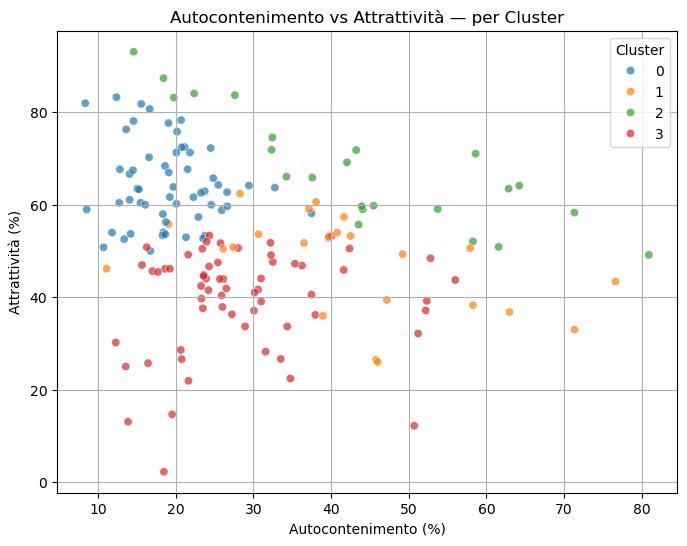

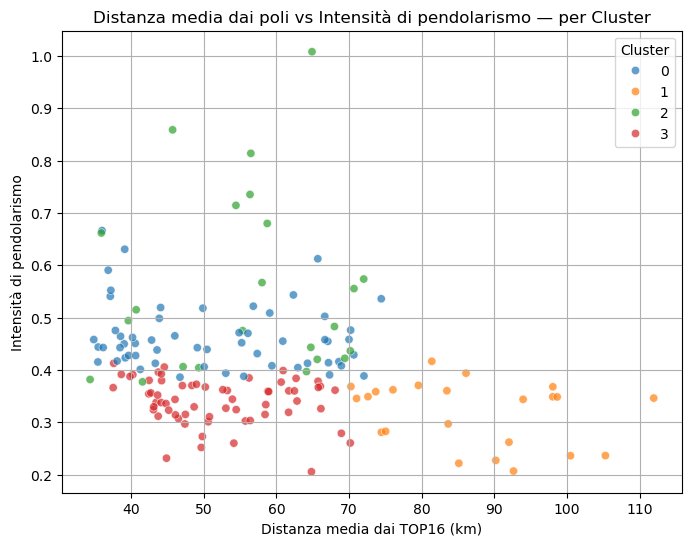

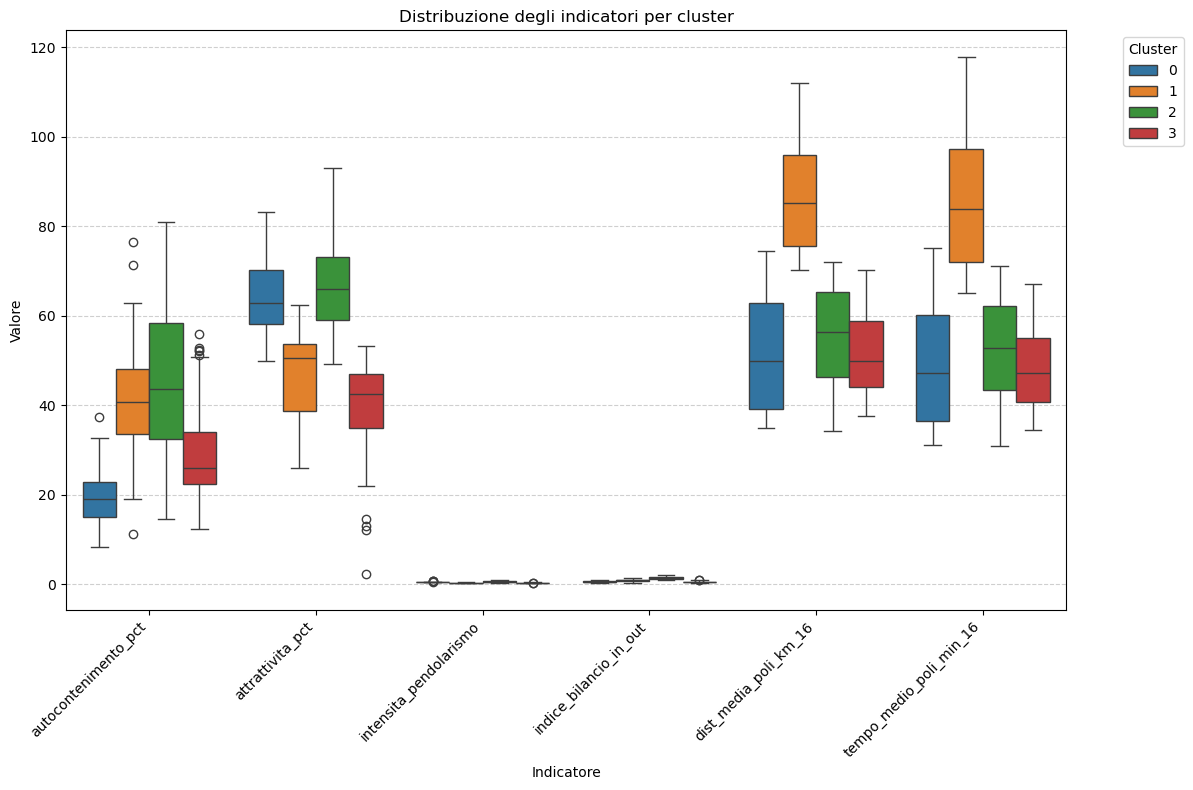

In [ ]:
# Punto 8: Visualizzazione dei cluster
# - Scatter plots per analisi visiva
# - Boxplots per distribuzione degli indicatori
# - Mappa del Trentino con comuni colorati per cluster


import seaborn as sns


# Caricamento dati
df = pd.read_csv(base / "indicatori_cluster.csv")
municipalities["id_comune"] = municipalities["id_comune"].astype(str).str.strip()
df["id_comune"] = df["id_comune"].astype(str).str.strip()

df_geo = df.merge(
    municipalities[["id_comune", "latitude", "longitude"]],
    on="id_comune", how="left"
)

# Imposta palette coerente per cluster
palette = sns.color_palette("tab10", n_colors=df["cluster"].nunique())

# -----------------------------
# Scatter 1: Autocontenimento vs Attrattività
# -----------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="autocontenimento_pct", y="attrattivita_pct",
    hue="cluster", palette=palette, alpha=0.7
)
plt.title("Autocontenimento vs Attrattività — per Cluster")
plt.xlabel("Autocontenimento (%)")
plt.ylabel("Attrattività (%)")
plt.grid(True)
plt.legend(title="Cluster", loc="best")
plt.show()

# -----------------------------
# Scatter 2: Distanza dai poli vs Intensità pendolarismo
# -----------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="dist_media_poli_km_16", y="intensita_pendolarismo",
    hue="cluster", palette=palette, alpha=0.7
)
plt.title("Distanza media dai poli vs Intensità di pendolarismo — per Cluster")
plt.xlabel("Distanza media dai TOP16 (km)")
plt.ylabel("Intensità di pendolarismo")
plt.grid(True)
plt.legend(title="Cluster", loc="best")
plt.show()


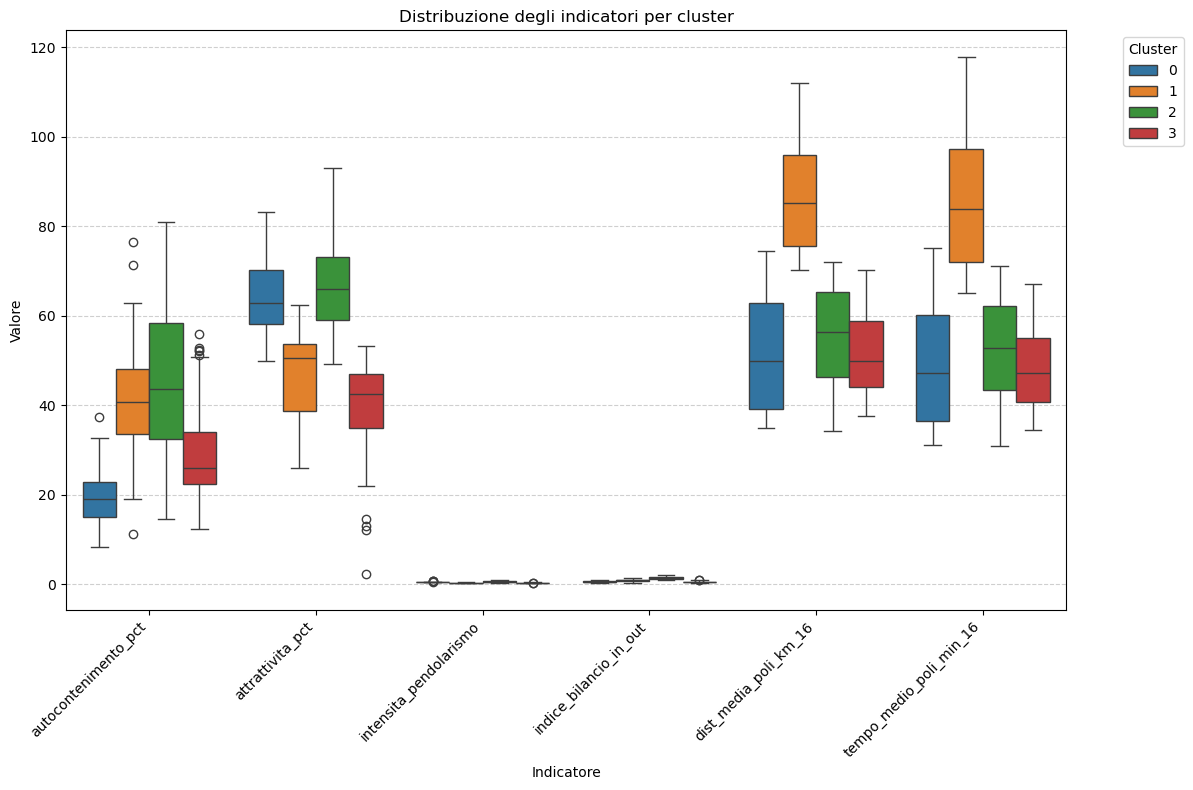

In [48]:

# -----------------------------
# Boxplots per ogni indicatore chiave
# -----------------------------
indicators = [
    "autocontenimento_pct", "attrattivita_pct",
    "intensita_pendolarismo", "indice_bilancio_in_out",
    "dist_media_poli_km_16", "tempo_medio_poli_min_16"
]

plt.figure(figsize=(12, 8))
df_melt = df.melt(id_vars="cluster", value_vars=indicators, var_name="Indicatore", value_name="Valore")
sns.boxplot(data=df_melt, x="Indicatore", y="Valore", hue="cluster", palette=palette)
plt.title("Distribuzione degli indicatori per cluster")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


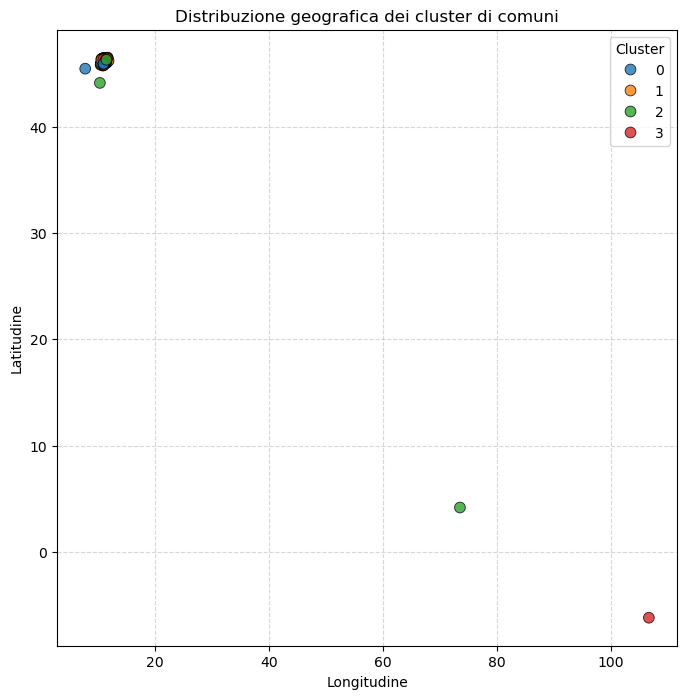

In [50]:

# -----------------------------
# Mappa dei comuni per cluster
# -----------------------------
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df_geo, x="longitude", y="latitude",
    hue="cluster", palette=palette, s=60, alpha=0.8, edgecolor="black"
)
plt.title("Distribuzione geografica dei cluster di comuni")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [ ]:
# Crea una mappa interattiva con sfondo OSM, comuni colorati per cluster,
# legenda con colori e una spiegazione sintetica per ogni cluster.
#
# Output: /mnt/data/mappa_cluster_comuni.html


import folium
from folium.plugins import MarkerCluster


# Carica dati cluster e anagrafica comuni (con coordinate)
df = pd.read_csv(base / "indicatori_cluster.csv")

# Allinea tipi chiave per il merge
df["id_comune"] = df["id_comune"].astype(str).str.strip()
municipalities["id_comune"] = municipalities["id_comune"].astype(str).str.strip()

# Merge per lat/lon
geo = df.merge(municipalities[["id_comune", "comune", "latitude", "longitude"]], on="id_comune", how="left")


# Crea una colonna 'comune' unificata qualunque sia il nome post-merge
if "comune" not in geo.columns:
    possibili = [c for c in geo.columns if c.startswith("comune")]
    # bfill prende il primo valore non-NaN da sinistra a destra
    geo["comune"] = geo[possibili].bfill(axis=1).iloc[:, 0]
    # pulizia opzionale
    for c in ("comune_x", "comune_y"):
        if c in geo.columns:
            geo.drop(columns=c, inplace=True)


# Centra la mappa sul baricentro geografico
center_lat = geo["latitude"].mean()
center_lon = geo["longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles="OpenStreetMap", control_scale=True)

# Palette colori per cluster (ricicla se cluster > palette)
palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf"
]
n_clusters = int(geo["cluster"].nunique())
colors = {c: palette[c % len(palette)] for c in sorted(geo["cluster"].unique())}

# Profilo medio per cluster (per descrizioni)
cols_cluster = [
    "autocontenimento_pct", "attrattivita_pct",
    "intensita_pendolarismo", "indice_bilancio_in_out",
    "dist_media_poli_km_16", "tempo_medio_poli_min_16"
]
profile = geo.groupby("cluster")[cols_cluster].mean().round(2)

# Genera etichette interpretative semplici per ciascun cluster
def label_cluster(row):
    auto = row["autocontenimento_pct"]
    attr = row["attrattivita_pct"]
    inten = row["intensita_pendolarismo"]
    distm = row["dist_media_poli_km_16"]
    # Heuristics semplici e leggibili
    if attr > auto and inten >= geo["intensita_pendolarismo"].median():
        return "Polo attrattivo"
    if auto >= 60 and distm >= geo["dist_media_poli_km_16"].median():
        return "Autosufficiente e distante"
    if inten < geo["intensita_pendolarismo"].quantile(0.25) and attr < geo["attrattivita_pct"].quantile(0.25):
        return "Bassa mobilità"
    return "Cintura/misto"

cluster_labels = {int(c): label_cluster(profile.loc[c]) for c in profile.index}

# Crea un FeatureGroup per ogni cluster per poter accendere/spegnere livelli
feature_groups = {c: folium.FeatureGroup(name=f"Cluster {c} — {cluster_labels.get(int(c), '')}", show=True) for c in colors.keys()}

# Marker (CircleMarker) per ciascun comune
for _, r in geo.iterrows():
    c = int(r["cluster"])
    color = colors[c]
    popup = folium.Popup(
        folium.IFrame(html=f"""
            <div style='font-family:Inter, system-ui, Arial; font-size:13px'>
            <b>{r['comune']}</b><br/>
            Cluster: <b>{c}</b> — {cluster_labels.get(c, '')}<br/><br/>
            <b>Autocontenimento</b>: {r['autocontenimento_pct']:.1f}%<br/>
            <b>Attrattività</b>: {r['attrattivita_pct']:.1f}%<br/>
            <b>Intensità pendolarismo</b>: {r['intensita_pendolarismo']:.3f}<br/>
            <b>Indice in/out</b>: {r['indice_bilancio_in_out']:.2f}<br/>
            <b>Distanza media TOP16</b>: {r['dist_media_poli_km_16']:.1f} km<br/>
            <b>Tempo medio TOP16</b>: {r['tempo_medio_poli_min_16']:.0f} min
            </div>
        """, width=280, height=220), max_width=320
    )
    folium.CircleMarker(
        location=[r["latitude"], r["longitude"]],
        radius=6,
        weight=1,
        color="#222",
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        opacity=0.9,
        popup=popup,
        tooltip=f"{r['comune']} — Cluster {c}"
    ).add_to(feature_groups[c])

# Aggiungi i feature group alla mappa
for fg in feature_groups.values():
    fg.add_to(m)

# Layer control
folium.LayerControl(collapsed=False).add_to(m)

# Legenda HTML con spiegazioni cluster
legend_items = ""
for c in sorted(colors.keys()):
    col = colors[c]
    label = cluster_labels.get(int(c), "")
    # Sintesi valori chiave del profilo
    p = profile.loc[c]
    legend_items += f"""
      <div style="display:flex; align-items:center; margin:4px 0">
        <span style="display:inline-block; width:14px; height:14px; background:{col}; border:1px solid #000; margin-right:8px"></span>
        <div>
          <div><b>Cluster {c}</b> — {label}</div>
          <div style="font-size:11px; color:#333">
            Auto {p['autocontenimento_pct']:.0f}% · Attr {p['attrattivita_pct']:.0f}% · Int {p['intensita_pendolarismo']:.2f} · dist {p['dist_media_poli_km_16']:.0f} km
          </div>
        </div>
      </div>
    """

legend_html = f"""
<div style="position: fixed; bottom: 20px; left: 20px; z-index: 9999; background: rgba(255,255,255,0.94);
            padding: 12px 14px; border: 1px solid #ccc; border-radius: 8px; box-shadow: 0 2px 8px rgba(0,0,0,0.15);
            font-family: Inter, system-ui, Arial; font-size: 12px; max-width: 360px;">
  <div style="font-weight: 700; margin-bottom: 6px;">Cluster dei comuni (profili sintetici)</div>
  {legend_items}
  <div style="font-size:11px; color:#666; margin-top:6px;">
    Sfondo: © OpenStreetMap contributors • Punti: centroidi comunali
  </div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Salva
out_path = base / "mappa_cluster_comuni.html"
m.save(str(out_path))
m

KeyError: 'comune'